# Genome-scale metabolic models

In [1]:
# Setup. On Google Colab this downloads the course files and installs the dependencies (~2 min).
# Locally (conda env from environment.yml) it only moves to the course folder so `data/` is found.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/cell-factory-design-course"):
        !git clone -q --depth 1 https://github.com/lab-biotek-bio-ugm/cell-factory-design-course /content/cell-factory-design-course
        %pip install -q --progress-bar off -r /content/cell-factory-design-course/requirements.txt
    from google.colab import output
    output.enable_custom_widget_manager()  # needed for Escher maps

for folder in (".", "..", "/content/cell-factory-design-course"):
    if os.path.isdir(os.path.join(folder, "data")):
        os.chdir(folder)
        break

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
Reason for being yanked: deprecated


## Overview

**Learning objectives.** After this notebook you can:
1. Navigate the metabolites, reactions and genes of a cobrapy model and look up their properties.
2. Interpret compartments, formulas, annotations and gene-protein-reaction (GPR) rules.
3. Relate the model objects to the stoichiometric matrix $S$ and to the FBA linear program.
4. Search a model for metabolites or reactions by name.
5. Recognize an infeasible optimization and explain why it happened.

**Estimated time:** 45 min.

**Prerequisites:** notebook 01.

### Background

A cobrapy `Model` has three main lists (`DictList`s): `model.metabolites`, `model.reactions` and `model.genes`. They are connected:

- A **metabolite** belongs to one **compartment** (cytosol `c`, periplasm `p`, extracellular `e` in *E. coli*). The same chemical in two compartments is two different metabolites, e.g. `glc__D_e` and `glc__D_p`, linked by transport reactions.
- A **reaction** has stoichiometric coefficients for its metabolites (negative for substrates, positive for products) and **flux bounds** (`lower_bound`, `upper_bound`, in mmol gDW⁻¹ h⁻¹). An irreversible reaction has `lower_bound = 0`. **Exchange reactions** (`EX_...`) move metabolites across the system boundary and define the medium.
- A **gene** is linked to reactions via **GPR rules**, Boolean expressions such as `b1723 or b3916` (isozymes: either gene is enough) or `b3731 and b3732` (subunits of one complex: all are needed). GPRs let us translate a gene knockout into the reactions it disables.

The stoichiometric coefficients of all reactions form the matrix $S$ (metabolites × reactions). FBA imposes $S v = 0$: for every internal metabolite, production equals consumption ([Orth et al., 2010](https://doi.org/10.1038/nbt.1614)). The **objective** (usually a biomass reaction that drains amino acids, nucleotides, lipids, cofactors etc. in the ratio found in dry cell mass) is what the solver maximizes.

The **ATP maintenance reaction** (`ATPM`) forces a minimal flux of ATP hydrolysis. It represents the energy the cell spends on things not included in the biomass reaction (turnover, maintaining gradients). This is *non-growth-associated* maintenance; the growth-associated part is included in the biomass reaction.

## Preparation

Load *i*JO1366 again.

In [2]:
from cobra.io import read_sbml_model
model = read_sbml_model('data/iJO1366.xml.gz')

## Model content

### Metabolites

The model contains a list of metabolites. Here are the first ten.

In [3]:
model.metabolites[0:10]

[<Metabolite 10fthf_c at 0x7cc5e2c86900>,
 <Metabolite 12dgr120_c at 0x7cc5e2c1f250>,
 <Metabolite 12dgr140_c at 0x7cc5e2c1f110>,
 <Metabolite 12dgr141_c at 0x7cc5e2c5cfc0>,
 <Metabolite 12dgr160_c at 0x7cc5e2c5cb00>,
 <Metabolite 12dgr161_c at 0x7cc5e2c89490>,
 <Metabolite 12dgr180_c at 0x7cc5e2ad8160>,
 <Metabolite 12dgr181_c at 0x7cc5e2ad8050>,
 <Metabolite 12ppd__R_c at 0x7cc5e2c78650>,
 <Metabolite 12ppd__S_c at 0x7cc5e2befe50>]

There are 1805 metabolites in the model.

In [4]:
len(model.metabolites)

1805

One can access a specific metabolite using dot notation.

In [5]:
model.metabolites.g3p_c

Metabolite identifier,g3p_c
Name,Glyceraldehyde 3-phosphate
Memory address,0x7cc5e29e42d0
Formula,C3H5O6P
Compartment,c
In 14 reaction(s),"TALA, DXPS, FBA, DDPGALA, DRPA, TKT1, GAPD, F6PA, TRPS3, TKT2, EDA, TGBPA, TRPS1, TPI"


<div class="alert alert-warning">

**Warning:** One cannot use dot notation to access metabolites, reactions, or genes if their identifiers do not resemble proper Python variable names.

</div>

In [6]:
# model.metabolites.10fthf_c  # uncomment to see the SyntaxError: identifiers can't start with a digit

<div class="alert alert-success">

**Solution:** Use the method `get_by_id` instead!

</div>

In [7]:
model.metabolites.get_by_id('10fthf_c')

Metabolite identifier,10fthf_c
Name,10-Formyltetrahydrofolate
Memory address,0x7cc5e2c86900
Formula,C20H21N7O7
Compartment,c
In 9 reaction(s),"AICART, MTHFC, ULA4NFT, FTHFD, BIOMASS_Ec_iJO1366_WT_53p95M, GARFT, FTHFLi, BIOMASS_Ec_iJO1366_core_53p95M, FMETTRS"


Metabolites are associated with compartments in the cell. Glyceraldehyde 3-phosphate (`g3p_c`) is associated with the `c` (Cytosol) compartment.

In [8]:
model.metabolites.g3p_c.compartment

'c'

The _E. coli_ model has three compartments.

In [9]:
model.compartments

{'c': 'cytosol', 'e': 'extracellular space', 'p': 'periplasm'}

Some metabolites (like Glucose for example) can be associated with multiple compartments.

In [10]:
model.metabolites.glc__D_c.compartment

'c'

In [11]:
model.metabolites.glc__D_p.compartment

'p'

The full name of the metabolite is available via the `.name` attribute.

In [12]:
model.metabolites.glc__D_c.name

'D-Glucose'

One can look up the molecular formula of a metabolite, here glyceraldehyde 3-phosphate. Formulas (and charges) are used to check that reactions are mass- and charge-balanced.

In [13]:
model.metabolites.g3p_c.formula

'C3H5O6P'

The `.elements` attribute returns a dictionary representation of the formula.

In [14]:
model.metabolites.g3p_c.elements

{'C': 3, 'H': 5, 'O': 6, 'P': 1}

Furthermore, one can look up the molecular weight of a metabolite.

In [15]:
model.metabolites.g3p_c.formula_weight

168.041961

One can gather additional information (like references to external databases) about the metabolite through the `annotation` attribute. Annotations are how you map model identifiers to KEGG, ChEBI, MetaNetX etc., for example when integrating omics data.

In [16]:
model.metabolites.g3p_c.annotation

{'sbo': 'SBO:0000247',
 'bigg.metabolite': 'g3p',
 'seed.compound': 'cpd00102',
 'metanetx.chemical': 'MNXM2378',
 'kegg.compound': ['C00118', 'C00661'],
 'hmdb': 'HMDB01112',
 'chebi': ['CHEBI:12983',
  'CHEBI:12984',
  'CHEBI:14333',
  'CHEBI:17138',
  'CHEBI:181',
  'CHEBI:18324',
  'CHEBI:21026',
  'CHEBI:29052',
  'CHEBI:5446',
  'CHEBI:58027',
  'CHEBI:59776'],
 'unipathway.compound': ['UPC00118', 'UPC00661'],
 'biocyc': 'META:GAP',
 'reactome': '29578'}

One can use these annotations to look up the compound on [KEGG](https://www.genome.jp/dbget-bin/www_bget?cpd:C00118) for example.

Metabolites are not isolated things. They participate in reactions as substrates and products.

In [17]:
model.metabolites.g3p_c.reactions

frozenset({<Reaction DDPGALA at 0x7cc5e1ed2c50>,
           <Reaction DRPA at 0x7cc5e1f89860>,
           <Reaction DXPS at 0x7cc5e1f8a620>,
           <Reaction EDA at 0x7cc5e1e38310>,
           <Reaction F6PA at 0x7cc5e1e390d0>,
           <Reaction FBA at 0x7cc5e1e3aa40>,
           <Reaction GAPD at 0x7cc5e1be1c80>,
           <Reaction TALA at 0x7cc5e1344e10>,
           <Reaction TGBPA at 0x7cc5e1345b20>,
           <Reaction TKT1 at 0x7cc5e1346c50>,
           <Reaction TKT2 at 0x7cc5e1346d00>,
           <Reaction TPI at 0x7cc5e13475f0>,
           <Reaction TRPS1 at 0x7cc5e1347d80>,
           <Reaction TRPS3 at 0x7cc5e1347ee0>})

### Reactions

The model contains a list of reactions. Here are the first 10 of them.

In [18]:
model.reactions[0:10]

[<Reaction DM_4crsol_c at 0x7cc5e2c86cf0>,
 <Reaction DM_5drib_c at 0x7cc5e2c1fb10>,
 <Reaction DM_aacald_c at 0x7cc5e2c1f9d0>,
 <Reaction DM_amob_c at 0x7cc5e2c5e520>,
 <Reaction DM_mththf_c at 0x7cc5e2c5e3f0>,
 <Reaction DM_oxam_c at 0x7cc5e2c896d0>,
 <Reaction BIOMASS_Ec_iJO1366_WT_53p95M at 0x7cc5e2ad87c0>,
 <Reaction BIOMASS_Ec_iJO1366_core_53p95M at 0x7cc5e2ad85a0>,
 <Reaction EX_12ppd__R_e at 0x7cc5e2c78e50>,
 <Reaction EX_12ppd__S_e at 0x7cc5e2c79050>]

There are 2583 reactions in the model.

In [19]:
len(model.reactions)

2583

Let's take a closer look at the reactions associated with Glyceraldehyde 3-phosphate (`g3p`).

In [20]:
for reaction in model.metabolites.g3p_c.reactions:
    print(reaction.id, reaction, reaction.name)

TALA TALA: g3p_c + s7p_c <=> e4p_c + f6p_c Transaldolase
DXPS DXPS: g3p_c + h_c + pyr_c --> co2_c + dxyl5p_c 1-deoxy-D-xylulose 5-phosphate synthase
FBA FBA: fdp_c <=> dhap_c + g3p_c Fructose-bisphosphate aldolase
DDPGALA DDPGALA: 2dh3dgal6p_c <=> g3p_c + pyr_c 2-dehydro-3-deoxy-6-phosphogalactonate aldolase
DRPA DRPA: 2dr5p_c --> acald_c + g3p_c Deoxyribose-phosphate aldolase
TKT1 TKT1: r5p_c + xu5p__D_c <=> g3p_c + s7p_c Transketolase
GAPD GAPD: g3p_c + nad_c + pi_c <=> 13dpg_c + h_c + nadh_c Glyceraldehyde-3-phosphate dehydrogenase
F6PA F6PA: f6p_c <=> dha_c + g3p_c Fructose 6-phosphate aldolase
TRPS3 TRPS3: 3ig3p_c --> g3p_c + indole_c Tryptophan synthase (indoleglycerol phosphate)
TKT2 TKT2: e4p_c + xu5p__D_c <=> f6p_c + g3p_c Transketolase
EDA EDA: 2ddg6p_c --> g3p_c + pyr_c 2-dehydro-3-deoxy-phosphogluconate aldolase
TGBPA TGBPA: tagdp__D_c <=> dhap_c + g3p_c Tagatose-bisphosphate aldolase
TRPS1 TRPS1: 3ig3p_c + ser__L_c --> g3p_c + h2o_c + trp__L_c Tryptophan synthase (indolegl

One of the reactions in this list is glyceraldehyde-3-phosphate dehydrogenase (GAPD), the glycolytic step that oxidizes G3P and produces NADH.

In [21]:
model.reactions.GAPD.name

'Glyceraldehyde-3-phosphate dehydrogenase'

## Objective

The objective is a linear expression over reaction fluxes. Printing it shows that the solver maximizes the flux through the core biomass reaction (both the forward and reverse variables of the reaction appear because cobrapy represents each reaction as two non-negative variables).

In [22]:
print(model.objective)

Maximize
1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1


## ATP maintenance requirement

Note the lower bound of `ATPM`: every solution must hydrolyse at least this much ATP (mmol gDW⁻¹ h⁻¹) for maintenance.

In [23]:
model.reactions.ATPM

Reaction identifier,ATPM
Name,ATP maintenance requirement
Memory address,0x7cc5e2139230
Stoichiometry,atp_c + h2o_c --> adp_c + h_c + pi_c ATP + H2O --> ADP + H+ + Phosphate
GPR,
Lower bound,3.15
Upper bound,1000.0


## The math (scary!)

This is the beginning of the actual optimization problem that cobrapy hands to the solver: one constraint per metabolite (the rows of $S v = 0$) and bounds per variable. You rarely need to look at it, but it shows that the model *is* just a linear program.

In [24]:
print(model.solver.__str__()[0:1550])

\* Problem: Unknown *\

Maximize
 obj: + BIOMASS_Ec_iJO1366_core_53p95M
 - BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1

Subject To
 r_1: + ULA4NFT_reverse_07217 - ULA4NFT - MTHFC_reverse_f6fcc + MTHFC
 + GARFT_reverse_7ecb6 - GARFT - FTHFLi_reverse_a6dc7 + FTHFLi
 + FTHFD_reverse_44321 - FTHFD + FMETTRS_reverse_3b6c6 - FMETTRS
 + AICART_reverse_b7b59 - AICART
 + 0.000223 BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1
 - 0.000223 BIOMASS_Ec_iJO1366_core_53p95M
 + 0.000223 BIOMASS_Ec_iJO1366_WT_53p95M_reverse_06c4a
 - 0.000223 BIOMASS_Ec_iJO1366_WT_53p95M = 0
 r_2: - PAPA120_reverse_75d70 + PAPA120 + DAGK120_reverse_7cd00
 - DAGK120 - s_666 + x_665 = 0
 r_3: - PAPA140_reverse_255f5 + PAPA140 + DAGK140_reverse_87f8f
 - DAGK140 - s_668 + x_667 = 0
 r_4: - PAPA141_reverse_945ab + PAPA141 + DAGK141_reverse_f6e5f
 - DAGK141 - s_670 + x_669 = 0
 r_5: - PAPA160_reverse_c64df + PAPA160 + DAGK160_reverse_0238d
 - DAGK160 - s_672 + x_671 = 0
 r_6: - PAPA161_reverse_1bc33 + PAPA161 + DAGK161_reverse

## Gene-Protein-Reaction associations

Glyceraldehyde-3-phosphate dehydrogenase is associated with a single gene.

In [25]:
model.reactions.GAPD.gene_reaction_rule

'b1779'

Phosphofructokinase (PFK) on the other hand is associated with two isozymes (`or`): knocking out one of the two genes does not block the reaction.

In [26]:
model.reactions.PFK.gene_reaction_rule

'b3916 or b1723'

One can display the gene names (typical 4 letter gene codes) instead of the identifiers (Blattner numbers in this case).

In [27]:
model.reactions.PFK.gene_name_reaction_rule

'pfkA or pfkB'

Here a very complicated gene to reaction mapping (ATP synthase): a multi-subunit complex (`and`), where some subunits can be provided by alternative genes.

In [28]:
model.reactions.ATPS4rpp.gene_name_reaction_rule

'(atpA and atpD and atpC and atpG and atpH and atpE and atpF and atpB and atpI) or (atpB and atpF and atpE and atpH and atpG and atpC and atpD and atpA)'

## Finding things

One can use `.query('search term', 'attribute_to_search_in')` to search in model metabolites, reactions, and genes. For example, one can search metabolites that contain the term _glucose_ in their name.

In [29]:
for metabolite in model.metabolites.query('glucose', 'name'):
    print(metabolite.name)

6-Acetyl-D-glucose
ADPglucose
DTDP-4-dehydro-6-deoxy-D-glucose
DTDPglucose
UDPglucose
UDPglucose
UDPglucose


## The stoichiometric matrix S

In [30]:
from cobra.util import create_stoichiometric_matrix
s = create_stoichiometric_matrix(model)
s

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., -1., -1.,  1.]])

This is how the stoichiometric matrix $S$ looks when visualized as a matrix plot (each dot is a non-zero coefficient). It is very sparse: most reactions involve only a handful of the 1805 metabolites. Horizontal lines are highly connected metabolites such as H⁺, H₂O, ATP and NAD(H).

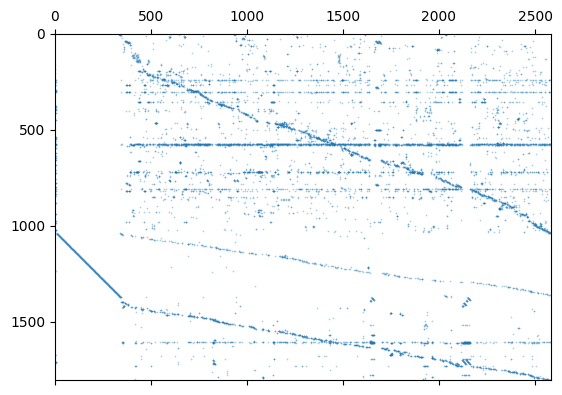

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.spy(s, precision=0.01, markersize=.1)

## Simulating models

In [32]:
model.optimize()

,fluxes,reduced_costs
DM_4crsol_c,0.000219,0.000000
DM_5drib_c,0.000221,0.000000
DM_aacald_c,0.000000,0.000000
DM_amob_c,0.000002,0.000000
DM_mththf_c,0.000440,0.000000
...,...,...
ZN2abcpp,0.000000,-0.008295
ZN2t3pp,0.000000,-0.002074
ZN2tpp,0.000335,0.000000
ZNabcpp,0.000000,-0.008295


Sometimes a solution cannot be found. For example, setting the lower bound of the objective function to a very high value that the model cannot achieve will trigger a warning when trying to optimize the model. Parameters reported from an infeasible model are not meaningful to interpret (except in rare occasions when you may want to figure out why a model is infeasible).

In [33]:
infeasible_model = model.copy()
infeasible_model.reactions.BIOMASS_Ec_iJO1366_core_53p95M.bounds = 100000, 100000
sol = infeasible_model.optimize()
sol.status

/usr/local/lib/python3.13/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


'infeasible'

`sol.status` is `infeasible`: no flux vector satisfies all constraints at the same time (the model cannot grow at 100000 h⁻¹). Always check `solution.status` (or use `model.slim_optimize(error_value=...)`) before interpreting results, especially in loops over many conditions.

## References

- Orth, Thiele, Palsson (2010). What is flux balance analysis? *Nature Biotechnology* 28:245–248. [doi.org/10.1038/nbt.1614](https://doi.org/10.1038/nbt.1614)